<a href="https://www.kaggle.com/code/gpreda/fine-tune-gemma-3-1b-using-lora-for-medical-q-a?scriptVersionId=236674133" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introduction


This notebook is based on a tutorial from goo.gle/ai-kaggle-keras-gemma about how to fine-tune **Gemma** on a **Kaggle** dataset and share the model with the community.  


## Model used

We are using **Gemma 3** model with 1B parameters, Keras, English version, v2.

## Dataset

We will fine-tune **Gemma 3** using a [Medical Q & A](https://www.kaggle.com/datasets/gpreda/medquad/) dataset. This is a subset of the full public dataset [Healthcare NLP: LLMs, Transformers, Datasets](https://www.kaggle.com/datasets/jpmiller/layoutlm).



# Prepare packages


We will install updated version of Keras, KerasNLP, which we need for fine-tuning, and other dependencies.

In [1]:
!pip install -q -U keras-nlp
!pip install -q -U keras>=3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.8.1 requires wurlitzer, which is not installed.
tensorflow-decision-forests 1.8.1 requires tensorflow~=2.15.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.15.1 requires tensorflow<2.16,>=2.15, but you have tensorflow 2.19.0 which is incompatible.


With Keras 3, we can run workflows on one of three backends: **TensorFlow**, **JAX**, and **PyTorch**.

For this Notebook, we will configure the backend for **JAX**.   

We are also setting the parameter `XLA_PYTHON_CLIENT_MEM_FRACTION` to avoid memory fragmentation on **JAX** backend.

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax" # you can also use tensorflow or torch
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.90" # avoid memory fragmentation on JAX backend.
os.environ["JAX_PLATFORMS"] = ""

Once installed the additional packages, we can now include them.

In [3]:
import keras
import keras_nlp
from keras_nlp.samplers import TopKSampler
from time import time
import csv

print("KerasNLP version: ", keras_nlp.__version__)
print("Keras version: ", keras.__version__)

2025-04-28 18:16:52.864222: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745864212.887889      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745864212.895280      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745864212.915214      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745864212.915250      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745864212.915253      24 computation_placer.cc:177] computation placer alr

KerasNLP version:  0.20.0
Keras version:  3.9.2


# Load the model

We load the model `gemma_3_1b` using `keras_nlp`.

In [4]:
gemma_lm = keras_nlp.models.Gemma3CausalLM.from_preset("/kaggle/input/gemma3/keras/gemma3_1b/3")

W0000 00:00:1745864219.211162      24 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Let's print the summary of the model loaded.

In [5]:
gemma_lm.summary()

Preprocessor: "gemma3_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma3_tokenizer (Gemma3Tokenizer)                            │                      Vocab size: 262,144 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma3_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma3_backbone               │ (None, None, 1152)        │     999,885,952 │ padding_mask[0][0],        │
│ (Gemma3Backbone)              │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 262144)      │     301,989,888 │ gemma3_backbone[0][0]      │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 999,885,952 (3.72 GB)

 Trainable params: 999,885,952 (3.72 GB)

 Non-trainable params: 0 (0.00 B)

# Prepare the training data

Let's create a configuration class.

In [6]:
class CFG:
 
    max_length = 256
    data_size = 1000

cfg = CFG()

We prepare the **Medical Q & A** data for training. We will load the data using the template where, for each data that will be included in the training set, we provide pairs of questions and answers.

In [7]:
data = []

# The CSV file contains two columns 'question' and 'answer'
with open("//kaggle/input/medquad/medquad.csv", mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        # we replace with 'prompts' and 'responses'
        data.append({"prompts": row['question'], 'responses': row['answer']})

In [8]:
print(f"Data size: {len(data)}")

Data size: 16412


Let's limit the data to **1000 rows** of questions and answers. We do this to limit the training time for this demonstration Notebook. You can get back and fine-tune using entire dataset or use your own data size.

In [9]:
data = data[:cfg.data_size]

We then prepare a dataset for training.

In [10]:
import tensorflow as tf

dataset = tf.data.Dataset.from_generator(
    lambda: (item for item in data),
    output_signature={
        "prompts": tf.TensorSpec(shape=(), dtype=tf.string),
        "responses": tf.TensorSpec(shape=(), dtype=tf.string),
    }
)

# Check model inference before fine tuning

We wil first check the model before proceeding to fine-tuning. We will test it with some questions about medical matters.  

First, we will define an utility function to display the query and answer from LLM.  

The first function is for the case when data is in text format.

In [11]:
from IPython.display import display, Markdown
def colorize_text(text):
    for word, color in zip(["Category", "Question", "Answer"], ["blue", "red", "green"]):
        text = text.replace(f"{word}:", f"\n\n**<font color='{color}'>{word}:</font>**")
    return text

The second function is for the case when data is in the dictionary format.

In [12]:
def colorize_text_dict(sample):
    """
    sample: dict with keys 'prompts' and 'responses'
    """
    colored_text = ""
    colored_text += f"**<font color='red'>Question:</font>** {sample['prompts']}\n\n"
    colored_text += f"**<font color='green'>Answer:</font>** {sample['responses']}\n\n"
    return colored_text

Let's check how we can display the content of one data input using the `colorize_text` function.

In [13]:
print(data[3])

{'prompts': 'What are the treatments for Glaucoma ?', 'responses': 'Although open-angle glaucoma cannot be cured, it can usually be controlled. While treatments may save remaining vision, they do not improve sight already lost from glaucoma. The most common treatments for glaucoma are medication and surgery. Medications  Medications for glaucoma may be either in the form of eye drops or pills. Some drugs reduce pressure by slowing the flow of fluid into the eye. Others help to improve fluid drainage. (Watch the video to learn more about coping with glaucoma. To enlarge the video, click the brackets in the lower right-hand corner. To reduce the video, press the Escape (Esc) button on your keyboard.) For most people with glaucoma, regular use of medications will control the increased fluid pressure. But, these drugs may stop working over time. Or, they may cause side effects. If a problem occurs, the eye care professional may select other drugs, change the dose, or suggest other ways to 

In [14]:
display(Markdown(colorize_text_dict(data[3])))

**<font color='red'>Question:</font>** What are the treatments for Glaucoma ?

**<font color='green'>Answer:</font>** Although open-angle glaucoma cannot be cured, it can usually be controlled. While treatments may save remaining vision, they do not improve sight already lost from glaucoma. The most common treatments for glaucoma are medication and surgery. Medications  Medications for glaucoma may be either in the form of eye drops or pills. Some drugs reduce pressure by slowing the flow of fluid into the eye. Others help to improve fluid drainage. (Watch the video to learn more about coping with glaucoma. To enlarge the video, click the brackets in the lower right-hand corner. To reduce the video, press the Escape (Esc) button on your keyboard.) For most people with glaucoma, regular use of medications will control the increased fluid pressure. But, these drugs may stop working over time. Or, they may cause side effects. If a problem occurs, the eye care professional may select other drugs, change the dose, or suggest other ways to deal with the problem.  Read or listen to ways some patients are coping with glaucoma. Surgery Laser surgery is another treatment for glaucoma. During laser surgery, a strong beam of light is focused on the part of the anterior chamber where the fluid leaves the eye. This results in a series of small changes that makes it easier for fluid to exit the eye. Over time, the effect of laser surgery may wear off. Patients who have this form of surgery may need to keep taking glaucoma drugs. Researching Causes and Treatments Through studies in the laboratory and with patients, NEI is seeking better ways to detect, treat, and prevent vision loss in people with glaucoma. For example, researchers have discovered genes that could help explain how glaucoma damages the eye. NEI also is supporting studies to learn more about who is likely to get glaucoma, when to treat people who have increased eye pressure, and which treatment to use first.



Now we will ask the model to answer to a question for which we know the expected answer.

Another example below:

In [15]:
prompt = {
    "prompts":"What are the treatments for Diabetes ?",
    "responses":""}
response = gemma_lm.generate(prompt, max_length=cfg.max_length)

answer = {"prompts": prompt["prompts"][0], "responses": response[len(prompt["prompts"][0]):]}
display(Markdown(colorize_text_dict(answer)))

**<font color='red'>Question:</font>** What are the treatments for Diabetes ?

**<font color='green'>Answer:</font>** 

Diabetes is a disease that affects the way your body uses sugar. It is a chronic condition that can be managed with diet, exercise, and medication.

There are different types of diabetes, each with its own treatment options.

Type 1 diabetes is an autoimmune disease that occurs when the body’s immune system attacks the insulin-producing cells in the pancreas. Type 1 diabetes is treated with insulin injections or an insulin pump.

Type 2 diabetes is the most common type of diabetes. It occurs when the body does not produce enough insulin or when the body cannot use insulin effectively. Type 2 diabetes is treated with diet, exercise, and medication.

Gestational diabetes is a type of diabetes that occurs during pregnancy. It is treated with diet, exercise, and medication.

Prediabetes is a condition in which blood sugar levels are higher than normal but not high enough to be diagnosed as diabetes. Prediabetes is treated with diet, exercise, and medication.

Diabetes is a serious condition that can lead to serious health problems if left untreated. It is important to seek medical attention if you have any symptoms of diabetes.

There are many different types of diabetes treatments available, including insulin injections, oral medications,



# Fine-tunning with LoRA   


We are using now **LoRA** for fine-tunning. **LoRA** stands for **Low Rank Adaptation** and is a method for modifying a pretrained model (for example, an LLM or vision transformer) to better suit a specific, often smaller, dataset by **adjusting only a small, low-rank subset of the model's parameters**.


The rank used here for LoRA controls the number of parameters that will be recalculated during fine-tuning.

In [16]:
# Enable LoRA for the model and set the LoRA rank to 4.
gemma_lm.backbone.enable_lora(rank=4)
gemma_lm.summary()

Preprocessor: "gemma3_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma3_tokenizer (Gemma3Tokenizer)                            │                      Vocab size: 262,144 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma3_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma3_backbone               │ (None, None, 1152)        │   1,000,538,240 │ padding_mask[0][0],        │
│ (Gemma3Backbone)              │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 262144)      │     301,989,888 │ gemma3_backbone[0][0]      │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,000,538,240 (3.73 GB)

 Trainable params: 652,288 (2.49 MB)

 Non-trainable params: 999,885,952 (3.72 GB)

In [17]:
# Fine-tune on the Medical QA dataset.

# Limit the input sequence length to 256 (to control memory usage).
gemma_lm.preprocessor.sequence_length = cfg.max_length
# Use AdamW (a common optimizer for transformer models).
optimizer = keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=0.01,
)
# Exclude layernorm and bias terms from decay.
optimizer.exclude_from_weight_decay(var_names=["bias", "scale"])

gemma_lm.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy()],
)
batched_dataset = dataset.batch(1)

history = gemma_lm.fit(batched_dataset, epochs=40)

Epoch 1/40
   1000/Unknown 203s 179ms/step - loss: 1.1280 - sparse_categorical_accuracy: 0.5923

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 203s 179ms/step - loss: 1.1280 - sparse_categorical_accuracy: 0.5923
Epoch 2/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 181s 162ms/step - loss: 1.0623 - sparse_categorical_accuracy: 0.6023
Epoch 3/40


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - loss: 1.0377 - sparse_categorical_accuracy: 0.6088
Epoch 4/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - loss: 1.0140 - sparse_categorical_accuracy: 0.6165
Epoch 5/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - loss: 0.9935 - sparse_categorical_accuracy: 0.6243
Epoch 6/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - loss: 0.9761 - sparse_categorical_accuracy: 0.6287
Epoch 7/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - loss: 0.9609 - sparse_categorical_accuracy: 0.6336
Epoch 8/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - loss: 0.9468 - sparse_categorical_accuracy: 0.6374
Epoch 9/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - loss: 0.9338 - sparse_categorical_accuracy: 0.6410
Epoch 10/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - loss: 0.9214 - sparse_categorical_accuracy: 0.6447
Epoch 11/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - loss: 0.9091 - sparse_categorical_accuracy: 0.6484
Epoch 12/4

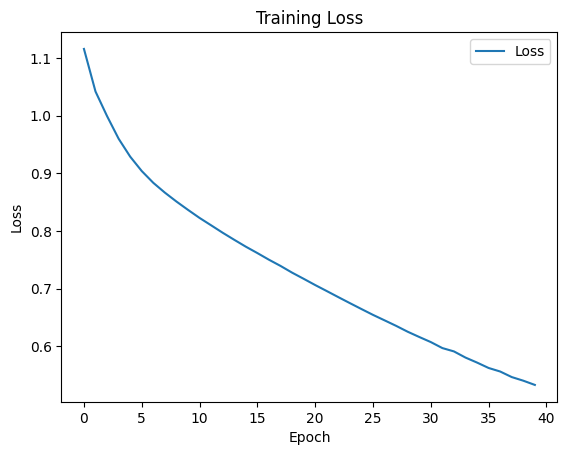

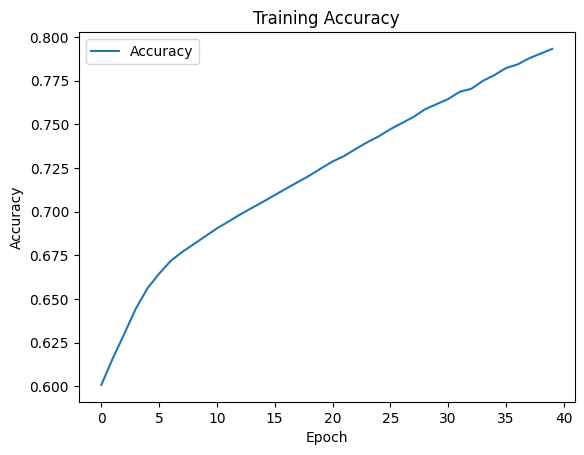

In [18]:
import matplotlib.pyplot as plt

loss = history.history['loss']
accuracy = history.history['sparse_categorical_accuracy']

# Plot Loss
plt.plot(loss, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

# Plot Accuracy
plt.plot(accuracy, label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

# Inference after fine tuning


Let's try again now the two examples from above. We will run now the queries through the fine-tuned model.

In [19]:
template = "Question:\n{question}\n\nAnswer:\n{answer}"
prompt = template.format(
    question="What are the complications of Paget's Disease of Bone ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What are the complications of Paget's Disease of Bone ?



**<font color='green'>Answer:</font>**
Paget's disease of bone can cause problems with the heart, lungs, and kidneys. The most common complications are bone fractures and joint problems.

Paget's disease of bone can cause problems with the heart, lungs, and kidneys. The most common complications are bone fractures and joint problems.

In [20]:
prompt = template.format(
    question="What are the treatments for Diabetes ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What are the treatments for Diabetes ?



**<font color='green'>Answer:</font>**
Diabetes insipidus occurs when the body does not make enough of a hormone called vasopressin to control the amount of water in the body. Diabetes insipidus is a rare disorder.

Diabetes is a disease in which the body has trouble regulating glucose, or blood, sugar. Diabetes is a group of diseases in which the blood has too much glucose, or sugar, Medical Test Results 18-06-2013_Diabetes_Diabetes_18_06_2013_Diabetes_Diabetes_1.pdf from the National Library of Medicine indicating high blood sugar over a long period of time. See also  Diabetes mellitus  and  Diabetes insipidus.

In [21]:
prompt = template.format(
    question="What are the symptoms of Glaucoma ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What are the symptoms of Glaucoma ?



**<font color='green'>Answer:</font>**
Glaucoma is a group of eye diseases that cause damage to the optic nerve. The optic nerve carries images from the eye to the brain. When the nerve is damaged, the brain cannot make full use of the images it receives. This damage leads to vision loss and even blindness.

The optic nerve carries images from the eye to the brain. When the nerve is damaged, the brain cannot make full use of the images received. This damage leads to vision loss and blindness.

There are two main types of glaucoma: open-angle glaucoma and closed-angle glaucoma.

Open-angle glaucoma is the most common form of the disease. It is the gradual buildup of pressure inside the eye. This buildup of pressure can damage the optic nerve and cause vision loss.

Closed-angle glaucoma is an acute form of the disease. It is a sudden blockage of the outflow channel in the eye. This blockage causes the pressure inside the eye to rise.

In [22]:
prompt = template.format(
    question="What are the treatments for Glaucoma ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What are the treatments for Glaucoma ?



**<font color='green'>Answer:</font>**
The following treatments are available for Glaucoma:
    - Surgery
    - Eye drops
    - Laser surgery
    - Other treatments
    - Medicines to control eye pressure.



Surgery
Glaucoma can be treated with surgery. The doctor places one or more of two types of implants in the eye. The first type, a trabecular-supportive implant, is a small piece of bone that is placed in the angle of the eye. The second type, a mesh implant, is a mesh that is placed in the chamber behind the iris. The mesh implant helps keep the iris from bulging.

Trabecular-supportive implants are placed in the angle of the eye. A trabecular-supportive implant is a small piece of bone that is placed in the angle of the eye. The mesh implant, which is placed in the chamber behind the iris, helps keep the iris from bulging.

Laser surgery
Laser surgery is a procedure that uses an intense beam of light to reshape the eye and reduce the pressure in the eye. The laser light is focused on the front of the eye where the nerve endings are. The surgery reduces the pressure in

In [23]:
prompt = template.format(
    question="What causes High Blood Pressure ?",
    answer="",
)
response = gemma_lm.generate(prompt, max_length=cfg.max_length)
display(Markdown(colorize_text(response)))



**<font color='red'>Question:</font>**
What causes High Blood Pressure ?



**<font color='green'>Answer:</font>**
There are two main types of high blood pressure, called primary and secondary high blood pressure.
Primary high blood pressure is high blood pressure that you have even though you have no other risk factors.
Secondary high blood pressure is high blood pressure that results from a condition or condition in which high blood pressure occurs as a side effect.
Learn more about primary and secondary high blood pressure.
Learn more about secondary high blood pressure.
What is diastolic blood pressure?
Diastolic blood pressure is the bottom number on your blood pressure reading. It is the bottom number diastolic blood pressure reading is the bottom number on your blood pressure reading. It is the bottom number diastolic blood volume. This is the bottom number diastolic blood volume. This is the number that shows how much blood your heart is pumping with each beat.
How do you measure blood pressure?
The blood pressure cuff used to take your blood pressure reading is called a sphygmomanometer. The first measurement is called the systolic blood pressure. The second measurement is called the diastolic blood pressure. The cuff used to measure your blood pressure is called a sphygmomanometer. The first measurement is called the systolic blood pressure. The second measurement

# Save the model

In [24]:
preset = "./medical_gemma3"
# Save the model to the preset directory.
gemma_lm.save_to_preset(preset)

# Conclusions

We saw how to fine tune **Gemma 3 1B"** model using **LoRA** and **KerasNLP**.

We only used a subset of the **Medical Q & A** data to perform the fine tuning. If you have access to more computational resources, please feel free to improve the fine-tuned model by:
* Adding more data from the available dataset.  
* Increasing the rank parameter used in fine-tuning.

We will use the saved model to publish a Kaggle Model.